In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [8]:
df = pd.read_csv("/Advertising Budget and Sales.csv")

In [9]:
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [10]:
df.tail()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [11]:
df.columns

Index(['Unnamed: 0', 'TV Ad Budget ($)', 'Radio Ad Budget ($)',
       'Newspaper Ad Budget ($)', 'Sales ($)'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales ($)                200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [13]:
df.describe()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [14]:
df.isnull().sum()

,0
Unnamed: 0,0
TV Ad Budget ($),0
Radio Ad Budget ($),0
Newspaper Ad Budget ($),0
Sales ($),0


In [15]:
df = df.rename(columns={
    'TV Ad Budget ($)': 'TV',
    'Radio Ad Budget ($)': 'Radio',
    'Newspaper Ad Budget ($)': 'Newspaper',
    'Sales ($)': 'Sales'
})

In [16]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.4649427  0.33160433]
Total Variance Explained: 0.7965470266726409


In [20]:
model = LinearRegression()
model.fit(X_train_pca, y_train)

LinearRegression()

In [21]:
y_pred = model.predict(X_test_pca)

print("First 5 Predictions:", y_pred[:5])

First 5 Predictions: [17.0655937  20.27435457 22.07560087 10.18496207 18.49382004]


In [22]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("MSE:", mse)
print("MAE:", mae)

R2 Score: 0.7865237084526809
MSE: 6.738078941656136
MAE: 2.0834172501795547


In [23]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 14.1
Coefficients: [2.49349496 3.58624493]


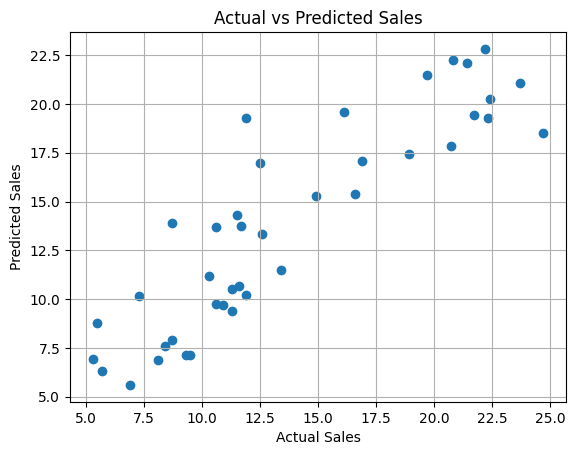

In [24]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.grid()
plt.show()

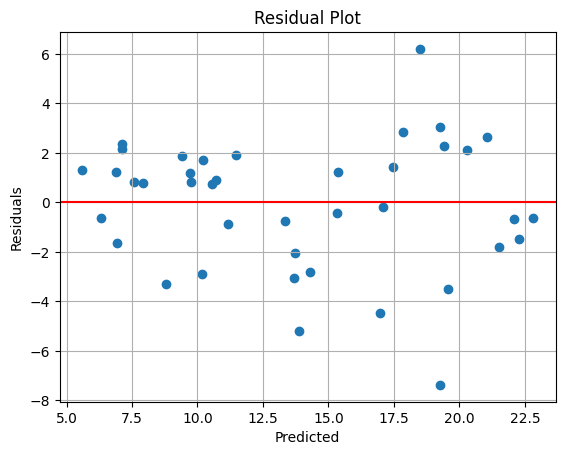

In [25]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid()
plt.show()

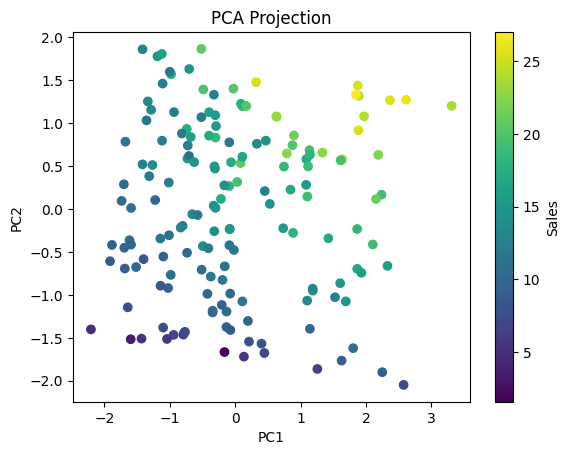

In [26]:
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.colorbar(label="Sales")
plt.show()

In [39]:
features = ['TV', 'Radio', 'Newspaper']

print("Feature Influence (in PCA-based regression space):")
for i, feature in enumerate(features):
    print(f"{feature}: {np.mean(model.coef_)} ")

Feature Influence (in PCA-based regression space):
TV: 3.039869946467385 
Radio: 3.039869946467385 
Newspaper: 3.039869946467385 


In [40]:
print("PCA Explained Variance Ratio:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.4f}")

PCA Explained Variance Ratio:
PC1: 0.4649
PC2: 0.3316


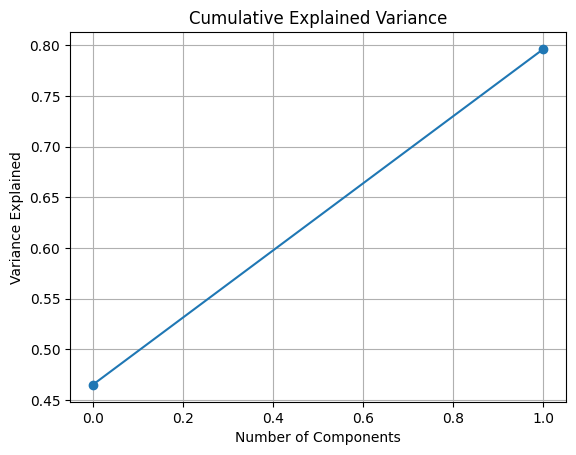

In [41]:
plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Variance Explained")
plt.grid()
plt.show()

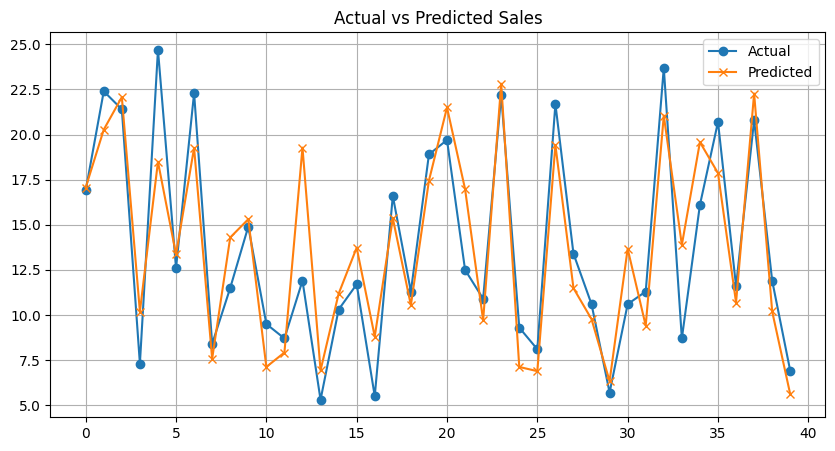

In [42]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual", marker='o')
plt.plot(y_pred, label="Predicted", marker='x')
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.grid()
plt.show()

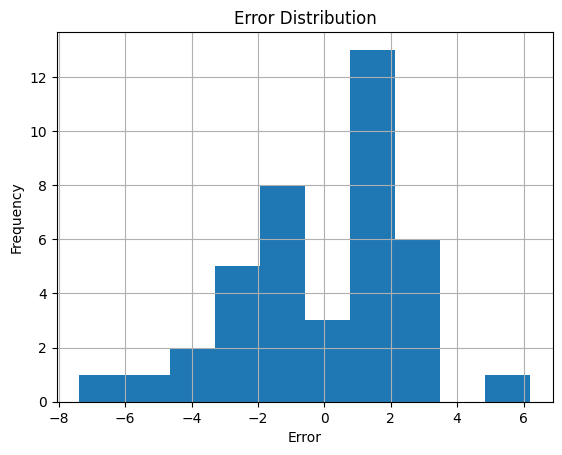

In [43]:
errors = y_test - y_pred

plt.hist(errors, bins=10)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.grid()
plt.show()

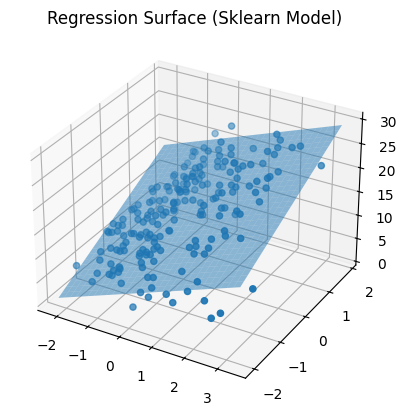

In [44]:
X_all = np.vstack([X_train_pca, X_test_pca])
y_all = np.hstack([y_train, y_test])

pc1_range = np.linspace(X_all[:,0].min(), X_all[:,0].max(), 30)
pc2_range = np.linspace(X_all[:,1].min(), X_all[:,1].max(), 30)

PC1, PC2 = np.meshgrid(pc1_range, pc2_range)

Z = model.intercept_ + model.coef_[0]*PC1 + model.coef_[1]*PC2

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(PC1, PC2, Z, alpha=0.5)
ax.scatter(X_all[:,0], X_all[:,1], y_all)

ax.set_title("Regression Surface (Sklearn Model)")
plt.show()

In [45]:
print("FINAL MODEL SUMMARY")
print("-------------------")
print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")

print("\nModel Components:")
print("PCA Components:", pca.n_components_)
print("Explained Variance:", sum(pca.explained_variance_ratio_))

print("\nConclusion:")
print("Model successfully reduces dimensionality and predicts sales using PCA + Linear Regression pipeline.")

FINAL MODEL SUMMARY
-------------------
R2 Score: 0.7865
MAE: 2.0834
MSE: 6.7381

Model Components:
PCA Components: 2
Explained Variance: 0.7965470266726409

Conclusion:
Model successfully reduces dimensionality and predicts sales using PCA + Linear Regression pipeline.
